# Phase 3 — Preprocessing

**Lifecycle:** Phase 3 (preprocess), Build stage. Work item: issue #22, branch `22-task-phase3-preprocessing`.
**Spec:** D-010 (Filter D + multi-detector pipeline). **Corpus:** cycle 3 alone (D-009). **Evidence base:** 04-eda.md.

Phase 3 saves the **unfitted pipeline definition** + per-column decisions. It does **not** split and does **not** `.fit()` — split + fit happen in Phase 6 on **train only** (guardrail #5).

## Part 1 — Data-quality audit (motivates the cleaning decisions)

D-010 settled Filter D + Stage 1 physical-bounds + Stage 2 within-trajectory interpolation (all *fit-free* → no leakage). Running the gate on the real corpus surfaces three things D-010 under-specifies (Findings A, B, C). This section documents them reproducibly; it **extends Phase 4 Insight 7** (which audited out-of-bounds *values* but not missingness, sequence length, or gap structure).

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / 'data' / 'raw' / 'opensky_states').exists():
            return c
    raise FileNotFoundError('repo root with data/raw/opensky_states not found')

ROOT = find_repo_root()
FIGDIR = ROOT / 'backend' / 'docs' / 'ml' / 'figures' / '03-preprocess'
FIGDIR.mkdir(parents=True, exist_ok=True)
files = sorted(glob.glob(str(ROOT / 'data' / 'raw' / 'opensky_states' / 'lemd_*.parquet')))
print(f'{len(files)} cycle-3 parquets')
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True).sort_values(['flight_id', 'time']).reset_index(drop=True)
print(f'{len(df):,} rows | {df.flight_id.nunique():,} trajectories | {df.icao24.nunique():,} aircraft')

18 cycle-3 parquets


3,429,638 rows | 19,057 trajectories | 2,470 aircraft


### Column inventory & feature selection

Before the findings: the raw corpus has 21 columns; the AE consumes a subset. This is the evidence for which columns are dropped (redundant / too-null / identity-not-kinematics) and which become AE inputs.

In [2]:
inv = pd.DataFrame({'dtype': df.dtypes.astype(str), 'null%': (df.isna().mean()*100).round(1)})
inv['role'] = 'drop'
for c in ['lat','lon','baroaltitude','velocity','vertrate','heading','onground']:
    if c in inv.index: inv.loc[c,'role'] = 'AE input'
print(inv.sort_values('role').to_string())
# the two non-obvious drops, demonstrated:
ratio = (df['velocity_kmh'] / df['velocity']).replace([np.inf,-np.inf], np.nan).dropna()
print(f"\nvelocity_kmh / velocity ratio: median={ratio.median():.3f}  -> exact x3.6 copy of velocity (redundant)")
print(f"geoaltitude null {df.geoaltitude.isna().mean()*100:.0f}% vs baroaltitude {df.baroaltitude.isna().mean()*100:.0f}% -> same quantity, keep the less-null baro")

                                dtype  null%      role
lat                           float64    0.0  AE input
lon                           float64    0.0  AE input
baroaltitude                  float64   13.5  AE input
velocity                      float64   13.4  AE input
heading                       float64   13.4  AE input
vertrate                      float64   13.3  AE input
onground                         bool    0.0  AE input
time                            int64    0.0      drop
icao24                            str    0.0      drop
geoaltitude                   float64   24.8      drop
callsign                          str    2.5      drop
squawk                        float64    2.0      drop
alert                            bool    0.0      drop
spi                              bool    0.0      drop
lastcontact                   float64    0.0      drop
flight_id                         str    0.0      drop
operation                         str    0.0      drop
time_utc  

**Reading.** `velocity_kmh` is `velocity` x3.6 exactly (redundant). `geoaltitude` is ~25% null vs baro's ~13% and encodes the same thing (keep baro). `icao24`/`flight_id`/`callsign`/`squawk`/`alert`/`spi`/`operation`/`time_utc`/`lastcontact` are identity or bookkeeping, not kinematics (and identity would let the AE memorise specific aircraft). **AE input = `[lat, lon, baroaltitude, velocity, vertrate, sin(heading), cos(heading), onground]`.**

### Finding A — missing values are structured (MNAR), concentrated on-ground

~13% of each kinematic column is genuine NaN. D-010 Stage 1 flags out-of-bounds values + the `velocity==0 @ altitude` placeholder, but gives **no policy for these true nulls**. Insight 7b caught the *zero*-placeholder pattern (2.81%); the `NaN` nulls below are a larger, separate population it did not flag. The table shows the nulls are tied to `onground` (MNAR).

In [3]:
KIN = ['velocity', 'heading', 'vertrate', 'baroaltitude']
rows = []
for c in KIN:
    rows.append({'feature': c,
                 'null%_all': df[c].isna().mean()*100,
                 'null%_onground': df.loc[df.onground==True, c].isna().mean()*100,
                 'null%_airborne': df.loc[df.onground==False, c].isna().mean()*100})
null_tbl = pd.DataFrame(rows).set_index('feature').round(1)
print('on-ground share of rows: %.1f%%' % (df.onground.mean()*100))
print(null_tbl.to_string())

on-ground share of rows: 20.0%
              null%_all  null%_onground  null%_airborne
feature                                                
velocity           13.4            55.8             2.8
heading            13.4            55.8             2.8
vertrate           13.3            55.7             2.8
baroaltitude       13.5            65.4             0.5


In [4]:
# Why n_imputed must be split into two counters: a single merged counter would select almost everyone.
any_kin_null = df.groupby('flight_id')[KIN].apply(lambda s: bool(s.isna().any().any()))
print(f'trajectories with >=1 routine kinematic NaN: {any_kin_null.mean()*100:.0f}%  ({int(any_kin_null.sum())}/{len(any_kin_null)})')
print('-> a single merged n_imputed>0 counter would select ~this share of the corpus, gutting the D-008 Layer-1 cohort.')
print('   the impossibility-only counter (Insight 7: ~0.0-0.08% of obs) stays small (~500-800 traj) and diagnostic.')

trajectories with >=1 routine kinematic NaN: 69%  (13179/19057)
-> a single merged n_imputed>0 counter would select ~this share of the corpus, gutting the D-008 Layer-1 cohort.
   the impossibility-only counter (Insight 7: ~0.0-0.08% of obs) stays small (~500-800 traj) and diagnostic.


In [5]:
def max_null_run(s):
    m = s.isna().to_numpy(); best=cur=0
    for v in m:
        cur = cur+1 if v else 0
        if cur>best: best=cur
    return best
runs = df.groupby('flight_id')['velocity'].apply(max_null_run)
p = {q:int(runs.quantile(q)) for q in (.5,.9,.99,1.0)}
print('per-trajectory max consecutive velocity-null run (10s steps):')
print(f"  P50={p[.5]}  P90={p[.9]}  P99={p[.99]}  max={p[1.0]}")
print(f"  P90={p[.9]} steps ~= {p[.9]*10/60:.0f} min -> long runs are parked/taxi on-ground")

per-trajectory max consecutive velocity-null run (10s steps):
  P50=0  P90=75  P99=172  max=1251
  P90=75 steps ~= 12 min -> long runs are parked/taxi on-ground


In [6]:
# Airborne-only null runs -- backs "airborne dropouts are SHORT" (the long runs above are on-ground)
air = df[df.onground == False]
air_runs = air.groupby('flight_id')['velocity'].apply(max_null_run)
print('airborne velocity-null run (10s steps): P50=%d P90=%d P99=%d max=%d' % tuple(int(air_runs.quantile(q)) for q in (.5,.9,.99,1.0)))
print('-> airborne dropouts are short -> linear interpolation is appropriate for them')

airborne velocity-null run (10s steps): P50=0 P90=17 P99=52 max=320
-> airborne dropouts are short -> linear interpolation is appropriate for them


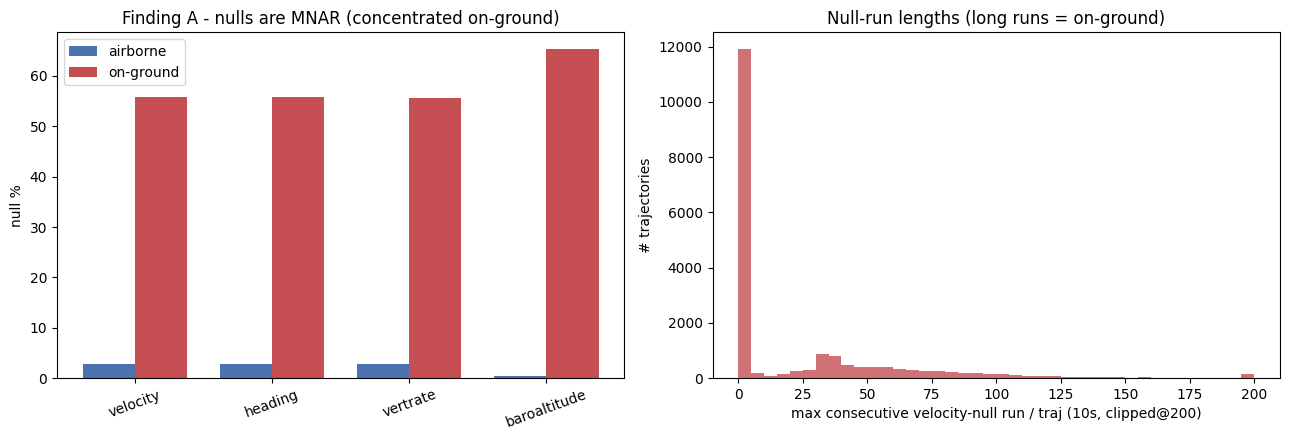

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax=axes[0]; x=np.arange(len(KIN)); w=0.38
ax.bar(x-w/2, null_tbl['null%_airborne'], w, label='airborne', color='#4C72B0')
ax.bar(x+w/2, null_tbl['null%_onground'], w, label='on-ground', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(KIN, rotation=20); ax.set_ylabel('null %')
ax.set_title('Finding A - nulls are MNAR (concentrated on-ground)'); ax.legend()
ax=axes[1]
ax.hist(runs.clip(upper=200), bins=40, color='#C44E52', alpha=0.8)
ax.set_xlabel('max consecutive velocity-null run / traj (10s, clipped@200)')
ax.set_ylabel('# trajectories'); ax.set_title('Null-run lengths (long runs = on-ground)')
plt.tight_layout(); plt.savefig(FIGDIR/'03a-missing-value-structure.png', dpi=110, bbox_inches='tight'); plt.show()

**Answer (Finding A).** The nulls are MNAR — concentrated on-ground (~56% of on-ground rows vs ~2.8% airborne). That rules out a single blanket rule, and it also rules out the two obvious shortcuts: `velocity=0` is wrong because the on-ground rows we *keep* are taxiing, not parked (Finding D), and deriving velocity from the position track fails exactly where we need it (Finding E). The surviving policy is **linear interpolation from recorded neighbours, within a segment, with a `*_missing` mask** on every filled value; truly-idle rows are trimmed (Finding D), so most on-ground nulls never reach the model. (Airborne velocity-null runs are short — P90 ≈ 17 steps — so interpolation is well-posed; the long runs in the chart above are on-ground.)

**Effect on Phase 4 / spec addenda:** Insight 7's out-of-bounds rates stand (NaN is not out-of-bounds); its "~99.9% kinematically normal" verdict is *incomplete* — silent on this ~13% missingness. Two addenda: **D-010 Stage 1** must handle `NaN` (not only `==0`); **D-008 Layer 1** cohort keys on impossibility-imputations only → split `n_imputed_impossible` (~500–800 trajectories) from `n_imputed_missing`, else `n_imputed>0` selects ~69% of the corpus (shown below) and the cohort is meaningless.

### Finding B — scale heterogeneity → scaling mandatory (guardrail #8)

The LSTM AE is gradient/distance-based; unscaled it is dominated by the highest-variance features and its reconstruction error (the anomaly score) ignores the rest.

In [8]:
FEAT = ['lat','lon','baroaltitude','velocity','vertrate','heading']
scale_tbl = df[FEAT].describe().T[['min','max','mean','std']].round(2)
scale_tbl['range'] = (scale_tbl['max']-scale_tbl['min']).round(2)
print(scale_tbl.to_string())

                 min       max     mean      std     range
lat            38.67     42.27    40.58     0.49      3.60
lon            -5.36     -1.76    -3.46     0.65      3.60
baroaltitude -365.76  38648.64  4750.74  3284.56  39014.40
velocity        0.00   1709.44   150.49    58.00   1709.44
vertrate     -139.48    165.81     0.08     7.11    305.29
heading        -0.00    359.92   189.37   112.74    359.92


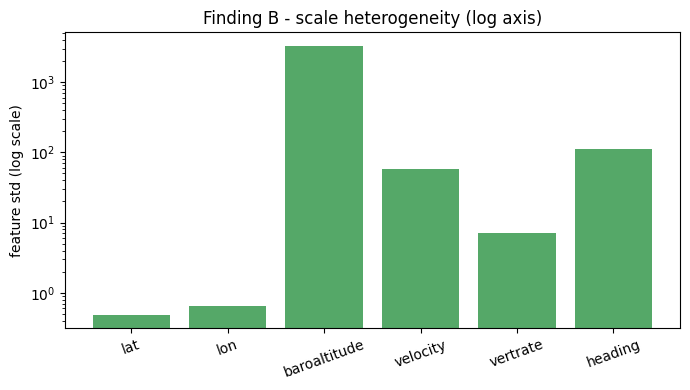

In [9]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(FEAT, scale_tbl['std'], color='#55A868')
ax.set_yscale('log'); ax.set_ylabel('feature std (log scale)')
ax.set_title('Finding B - scale heterogeneity (log axis)')
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(FIGDIR/'03b-scale-heterogeneity.png', dpi=110, bbox_inches='tight'); plt.show()

**Answer (Finding B).** `baroaltitude` std (~3.3k) is ~4 orders above `lat` std (~0.49). Scaling is a *fitted* transform → `.fit()` on **train only** in Phase 6, transform everywhere (guardrails #5, #8). Decision: **StandardScaler** on `[lat, lon, baroaltitude, velocity, vertrate]`; **not** the sin/cos heading pair (already [-1,1]) and **not** `onground` (binary). `heading` is cyclic (0/360) → sin/cos encode before scaling.

### Finding C — sequence design: length, the artifact tail, and gap structure

The LSTM AE needs a fixed-shape `(T, n_features)` tensor, but trajectories are variable-length. Before choosing `T` we characterise the length distribution and **what drives its tail** — otherwise we size the tensor for artifacts.

In [10]:
g = df.groupby('flight_id')
length = g.size()
print('trajectory length (rows @10s):')
for q in [.5,.75,.9,.95,.99,1.0]:
    print(f'  P{int(q*100):>3}: {int(length.quantile(q)):>5} rows (~{length.quantile(q)*10/60:>4.0f} min)')
print('\ntruncation vs padding trade-off (pad everyone to T):')
print(f"{'T':>6} {'trunc%':>8} {'padding%':>9}")
for T in [180,220,276,378,int(length.max())]:
    trunc=(length>T).mean()*100
    padded=np.clip(T-length,0,None).sum(); kept=np.clip(length,0,T).sum()
    print(f'{T:>6} {trunc:>8.1f} {padded/(padded+kept)*100:>9.1f}')

trajectory length (rows @10s):
  P 50:   175 rows (~  29 min)
  P 75:   214 rows (~  36 min)
  P 90:   251 rows (~  42 min)
  P 95:   276 rows (~  46 min)
  P 99:   378 rows (~  63 min)
  P100:  1606 rows (~ 268 min)

truncation vs padding trade-off (pad everyone to T):
     T   trunc%  padding%
   180     46.3      13.3
   220     21.9      22.9
   276      5.0      36.2
   378      1.0      52.8
  1606      0.0      88.8


**Reading.** "Never truncate" = pad everyone to max (1606) = **~89% of every tensor is padding** (the LSTM forward-processes fake steps; masking fixes the *loss*, not the *compute*). To choose `T` sensibly we need to know whether the long tail is signal or artifact.

In [11]:
# What drives the tail? Characterise trajectories above P99.
ongr = g['onground'].mean(); maxgap = g['time'].apply(lambda s: s.diff().max())
P99 = length.quantile(.99); long_ids = length[length>P99].index
tail = pd.DataFrame({'len':length,'onground_frac':ongr,'maxgap_s':maxgap}).loc[long_ids]
gappy = tail[tail.maxgap_s>300]; cont = tail[tail.maxgap_s<=300]
print(f'{len(long_ids)} trajectories above P99 ({int(P99)} rows). TWO populations:')
print(f'  (1) gappy (maxgap>5min):        {len(gappy):>3}  mean onground={gappy.onground_frac.mean():.2f}  <- coverage holes / merged ops')
print(f'  (2) continuous parked (<=5min): {len(cont):>3}  mean onground={cont.onground_frac.mean():.2f}  mean len={cont.len.mean():.0f}  <- hours of on-ground broadcast')
print('\ntop-3 longest:')
print(tail.sort_values('len',ascending=False).head(3).round(2).to_string())

191 trajectories above P99 (378 rows). TWO populations:
  (1) gappy (maxgap>5min):         97  mean onground=0.53  <- coverage holes / merged ops
  (2) continuous parked (<=5min):  94  mean onground=0.46  mean len=529  <- hours of on-ground broadcast

top-3 longest:
                    len  onground_frac  maxgap_s
flight_id                                       
c058aa_1580736720  1606           0.07     470.0
e06588_1569809690  1458           0.89     210.0
34520c_1543810660  1412           0.87     140.0


In [12]:
# Gap structure + effect of an internal-gap SPLIT threshold (the choice is NOT insensitive)
gap = g['time'].diff().dropna()
print('inter-observation gap distribution: 99.6% are the 10s cadence. The thin tail:')
for lo,hi,lab in [(15,70,'10-60s (missed beacon)'),(70,180,'1-3 min'),(180,600,'3-10 min'),(600,1800,'10-30 min')]:
    print(f'    {lab:22s}: {((gap>lo)&(gap<=hi)).mean()*100:6.3f}%')
print()
print('split-threshold effect (re-segment at internal gap > G):')
print(f"{'G':>6} {'+splits':>8} {'P95':>5} {'P99':>5} {'max':>6}")
for G,lab in [(90,'90s'),(180,'3min'),(300,'5min'),(600,'10min'),(900,'15min')]:
    cut=(g['time'].diff()>G); subid=cut.groupby(df['flight_id']).cumsum()
    L=df.groupby([df['flight_id'],subid]).size()
    print(f'{lab:>6} {int((gap>G).sum()):>8} {int(L.quantile(.95)):>5} {int(L.quantile(.99)):>5} {int(L.max()):>6}')
print('chosen: split at > 3 min. Linear interp is credible only for short dropouts (<=~90s);')
print('a gap beyond a few minutes is a genuine discontinuity the 10s-grid AE cannot represent. This is a real choice, not insensitive.')

inter-observation gap distribution: 99.6% are the 10s cadence. The thin tail:
    10-60s (missed beacon):  0.241%
    1-3 min               :  0.047%
    3-10 min              :  0.066%
    10-30 min             :  0.010%

split-threshold effect (re-segment at internal gap > G):
     G  +splits   P95   P99    max
   90s     3828   261   320   1251


  3min     2598   266   329   1497
  5min     1509   269   335   1497
 10min      354   274   347   1606


 15min      154   275   350   1606
chosen: split at > 3 min. Linear interp is credible only for short dropouts (<=~90s);
a gap beyond a few minutes is a genuine discontinuity the 10s-grid AE cannot represent. This is a real choice, not insensitive.


In [13]:
def haversine_km(a1, o1, a2, o2):
    R = 6371.0
    p1, p2 = np.radians(a1), np.radians(a2)
    dp, dl = np.radians(a2 - a1), np.radians(o2 - o1)
    h = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(h, 0, 1)))  # clip for float safety

# Per-step time gap, displacement, and SPEED (displacement / dt -- NOT assumed 10s).
gd2 = df.groupby('flight_id')
df['_dt']     = gd2['time'].diff()
df['_step_m'] = haversine_km(gd2['lat'].shift(), gd2['lon'].shift(), df.lat, df.lon) * 1000.0
df['_speed']  = df['_step_m'] / df['_dt']
pong = gd2['onground'].shift()
m = df['_dt'] > 180
print(f'{int(m.sum())} gaps > 3 min:')
print(f'  spatial jump (km):   median={(df["_step_m"][m]/1000).median():.1f}  P90={(df["_step_m"][m]/1000).quantile(.9):.1f}  max={(df["_step_m"][m]/1000).max():.1f}')
print(f'  implied speed (m/s): median={df["_speed"][m].median():.1f}  P90={df["_speed"][m].quantile(.9):.1f}')
print(f'  onground at gap:     before={pong[m].mean()*100:.0f}%  after={df.onground[m].mean()*100:.0f}%')
print(f'  jump <2 km (clearly stationary): {((df["_step_m"][m]/1000)<2).mean()*100:.0f}%')
print('  -> median jump 3.4 km, ~53% bracket on-ground: NOT fast spatial teleports.')
print('     Whatever the cause, the TEMPORAL discontinuity breaks the 10s grid -> we split (see Finding C answer).')

2598 gaps > 3 min:
  spatial jump (km):   median=3.4  P90=8.2  max=218.9
  implied speed (m/s): median=9.5  P90=28.8
  onground at gap:     before=53%  after=55%
  jump <2 km (clearly stationary): 23%
  -> median jump 3.4 km, ~53% bracket on-ground: NOT fast spatial teleports.
     Whatever the cause, the TEMPORAL discontinuity breaks the 10s grid -> we split (see Finding C answer).


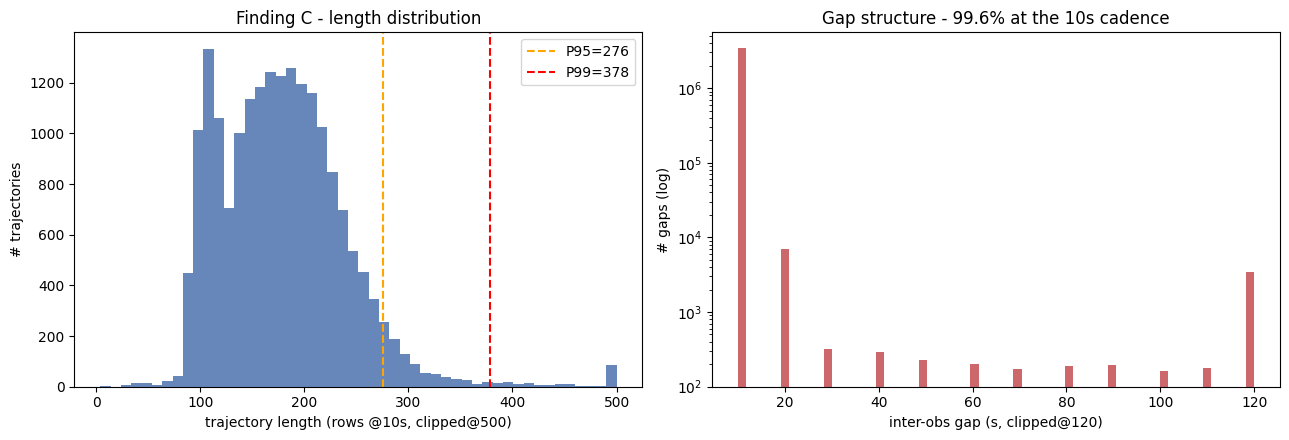

In [14]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
ax=axes[0]
ax.hist(length.clip(upper=500),bins=50,color='#4C72B0',alpha=.85)
for q,c in [(.95,'orange'),(.99,'red')]:
    ax.axvline(length.quantile(q),color=c,ls='--',label=f'P{int(q*100)}={int(length.quantile(q))}')
ax.set_xlabel('trajectory length (rows @10s, clipped@500)'); ax.set_ylabel('# trajectories')
ax.set_title('Finding C - length distribution'); ax.legend()
ax=axes[1]
ax.hist(gap.clip(upper=120),bins=60,color='#C44E52',alpha=.85); ax.set_yscale('log')
ax.set_xlabel('inter-obs gap (s, clipped@120)'); ax.set_ylabel('# gaps (log)')
ax.set_title('Gap structure - 99.6% at the 10s cadence')
plt.tight_layout(); plt.savefig(FIGDIR/'03c-length-and-gap-structure.png',dpi=110,bbox_inches='tight'); plt.show()

**Answer (Finding C).** The length tail is **two distinct pathologies**, each needing a different tool:

1. **Gappy trajectories** (~half the tail; internal time-voids up to ~30 min). *Measured* (jump cell): median straight-line jump only **3.4 km**, ~53% bracket an on-ground state — i.e. **not fast spatial teleports**. But the *temporal* discontinuity is real regardless of displacement: the AE reads every step as 10 s apart, so a multi-minute hole secretly makes one step span minutes. **Fix: re-segment at an internal-gap threshold** — the temporal twin of D-010's >5 km teleport guard.
   The threshold is a **real choice, not insensitive** (codex corrected an earlier claim of mine): split counts are 90s→3828, 3min→2598, 5min→1509, 10min→354, 15min→154. We pick **> 3 min** — interpolation is only credible for short dropouts (≤~90 s), so anything beyond a few minutes is split, not interpolated. (10 min was too loose: it left 3–10 min gaps intact.)

2. **Continuous-parked trajectories** (~half the tail; mean on-ground ~0.5–0.9, e.g. the 1458-row track at 89% on-ground) — an aircraft broadcasting while parked for hours. *Continuous* (no gap → gap-split won't touch them), so bounded instead by **fixed-T truncation** and the Finding-D idle-trim.

**Gap-split and fixed-T are complementary:** gap-split guarantees *continuity / uniform sampling*; fixed-T bounds *length*. Decision: **fixed T ≈ P95 + pad/mask + internal-gap split at > 3 min**, with `T` computed on **train only** (the P95 ≈ 276 shown here is full-corpus EDA, not the locked value — computing it on the full corpus would leak length into the pipeline). **Order matters: split first, then interpolate only within a segment** (never across a break).

### Finding D — on-ground structure: operational movement vs parked idle

The on-ground trim must keep the *active operation* (taxi-out, departure queue/wait, takeoff, touchdown, rollout, taxi-in) and drop only the *parked idle* before the operation starts and after it ends. `velocity` can't define "moving" — it is null ~56% of the time on-ground (Finding A) and 0 when stationary. **Position is never null**, so we detect movement from per-step lat/lon displacement. A departure queue shows small-but-nonzero creep; a parked plane shows ~zero displacement.

In [15]:
print('null %%:  lat=%.2f  lon=%.2f  velocity_all=%.1f  velocity_onground=%.1f' % (
    df.lat.isna().mean()*100, df.lon.isna().mean()*100,
    df.velocity.isna().mean()*100, df.loc[df.onground==True,'velocity'].isna().mean()*100))
print('-> position never null; velocity null on most on-ground rows -> use displacement, not velocity')

null %:  lat=0.00  lon=0.00  velocity_all=13.4  velocity_onground=55.8
-> position never null; velocity null on most on-ground rows -> use displacement, not velocity


In [16]:
# Movement signal = SPEED (m/s), dt-normalised. (Raw per-step displacement was NOT divided by dt -- fixed in the gap cell above.)
og = df[(df.onground == True) & df['_speed'].notna()]
print('on-ground SPEED (m/s), dt-normalised:')
for q in [.5,.75,.9,.95,.99]:
    print(f'  P{int(q*100):>3}: {og["_speed"].quantile(q):7.2f} m/s')
print(f'  < 0.5 m/s (parked / jitter):  {(og["_speed"]<0.5).mean()*100:5.1f}%')
print(f'  0.5-2.5 m/s (creep / queue):  {((og["_speed"]>=0.5)&(og["_speed"]<2.5)).mean()*100:5.1f}%')
print(f'  >= 2.5 m/s (active taxi):     {(og["_speed"]>=2.5).mean()*100:5.1f}%')
print('  (typical taxi 5-15 m/s; parked ~0; 2.5 m/s sits below taxi, above creep)')

on-ground SPEED (m/s), dt-normalised:
  P 50:    0.00 m/s
  P 75:    2.16 m/s
  P 90:   10.69 m/s
  P 95:   22.79 m/s
  P 99:   99.16 m/s
  < 0.5 m/s (parked / jitter):   71.7%
  0.5-2.5 m/s (creep / queue):    3.9%
  >= 2.5 m/s (active taxi):      24.4%
  (typical taxi 5-15 m/s; parked ~0; 2.5 m/s sits below taxi, above creep)


In [17]:
MOVE_THRESH_MS = 2.5  # m/s -- domain constant (below typical taxi 5-15 m/s, above parked creep), NOT a data-fit parameter
df['_active'] = (df.onground == False) | (df['_speed'] > MOVE_THRESH_MS)

def idle_runs(sub):
    a = sub['_active'].to_numpy(); n = len(a)
    has_air = bool((~sub['onground']).any())
    if not a.any():
        return pd.Series({'lead_idle': n, 'trail_idle': 0, 'has_air': has_air})
    first = int(a.argmax()); last = n - 1 - int(a[::-1].argmax())
    return pd.Series({'lead_idle': first, 'trail_idle': n - 1 - last, 'has_air': has_air})

spans = df.groupby('flight_id', group_keys=False).apply(idle_runs)
qs = (.5,.9,.99,1.0)
print('leading-idle run (rows before first movement/airborne):  P50=%d P90=%d P99=%d max=%d' % tuple(int(spans['lead_idle'].quantile(q)) for q in qs))
print('trailing-idle run (rows after last movement/airborne):   P50=%d P90=%d P99=%d max=%d' % tuple(int(spans['trail_idle'].quantile(q)) for q in qs))
no_air = ~spans['has_air']
print(f'\npure-ground trajectories (no airborne portion): {int(no_air.sum())} of {len(spans)} ({no_air.mean()*100:.1f}%)')
trim_rows = int(spans['lead_idle'].sum() + spans['trail_idle'].sum())
print(f'rows trimmed by idle-trim rule: {trim_rows:,} ({trim_rows/len(df)*100:.1f}% of all rows)')

leading-idle run (rows before first movement/airborne):  P50=0 P90=8 P99=43 max=677
trailing-idle run (rows after last movement/airborne):   P50=0 P90=30 P99=35 max=1218

pure-ground trajectories (no airborne portion): 68 of 19057 (0.4%)
rows trimmed by idle-trim rule: 201,710 (5.9% of all rows)


In [18]:
# Missingness by MOVEMENT state -- what the imputation policy must key on (not just onground)
for label, mask in [('airborne',                          df.onground==False),
                    ('on-ground ACTIVE (taxi -> kept)',    (df.onground==True)&(df['_speed']>MOVE_THRESH_MS)),
                    ('on-ground IDLE (parked -> trimmed)', (df.onground==True)&(df['_speed']<=MOVE_THRESH_MS))]:
    sub = df[mask]
    print(f'{label:36s}: {len(sub):>9,} rows | velocity null {sub.velocity.isna().mean()*100:5.1f}%')
print('-> velocity=0 imputation is valid ONLY for IDLE rows (which we trim anyway).')
print('   ACTIVE on-ground nulls (taxiing) must be imputed from motion (displacement/dt) or interpolated, NOT set to 0.')

airborne                            : 2,745,248 rows | velocity null   2.8%
on-ground ACTIVE (taxi -> kept)     :   165,857 rows | velocity null  56.5%
on-ground IDLE (parked -> trimmed)  :   512,553 rows | velocity null  55.1%
-> velocity=0 imputation is valid ONLY for IDLE rows (which we trim anyway).
   ACTIVE on-ground nulls (taxiing) must be imputed from motion (displacement/dt) or interpolated, NOT set to 0.


In [19]:
# Eyeball: the trajectory with the largest trailing-idle (parked after landing)
ex = spans.sort_values('trail_idle', ascending=False).index[0]
t = df[df.flight_id == ex]
print(f'Largest trailing-idle (parked after landing): {ex}')
print(f'  rows={len(t)}  onground_frac={t.onground.mean():.2f}  trail_idle={int(spans.loc[ex,"trail_idle"])}')
print(f'  last 10 per-step displacements (m): {[round(x,1) for x in t["_step_m"].tail(10).tolist()]}')
print('  -> displacement collapses to ~0: plane parked and kept broadcasting (this tail is what we trim)')

Largest trailing-idle (parked after landing): e06588_1569809690
  rows=1458  onground_frac=0.89  trail_idle=1218
  last 10 per-step displacements (m): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  -> displacement collapses to ~0: plane parked and kept broadcasting (this tail is what we trim)


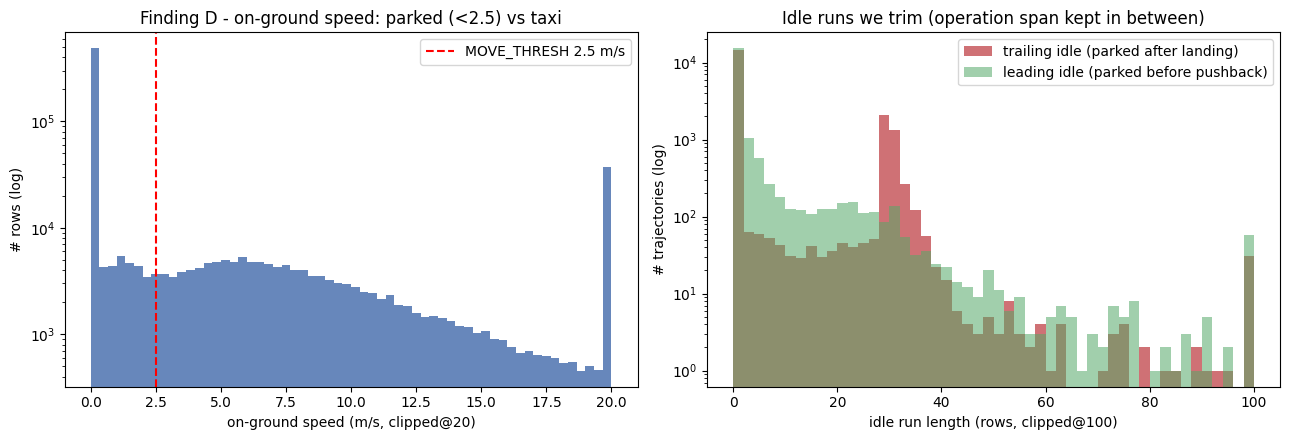

In [20]:
# Finding D figure: on-ground speed split + the idle runs we trim
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ogspd = df.loc[df.onground == True, '_speed'].dropna()
ax.hist(ogspd.clip(upper=20), bins=60, color='#4C72B0', alpha=.85)
ax.axvline(2.5, color='red', ls='--', label='MOVE_THRESH 2.5 m/s')
ax.set_yscale('log'); ax.set_xlabel('on-ground speed (m/s, clipped@20)'); ax.set_ylabel('# rows (log)')
ax.set_title('Finding D - on-ground speed: parked (<2.5) vs taxi'); ax.legend()
ax = axes[1]
ax.hist(spans['trail_idle'].clip(upper=100), bins=50, color='#C44E52', alpha=.8, label='trailing idle (parked after landing)')
ax.hist(spans['lead_idle'].clip(upper=100), bins=50, color='#55A868', alpha=.55, label='leading idle (parked before pushback)')
ax.set_yscale('log'); ax.set_xlabel('idle run length (rows, clipped@100)'); ax.set_ylabel('# trajectories (log)')
ax.set_title('Idle runs we trim (operation span kept in between)'); ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR/'03d-onground-movement.png', dpi=110, bbox_inches='tight'); plt.show()

**Answer (Finding D).** Movement is detected from **speed = displacement / dt** (m/s, dt-normalised) — `velocity` cannot define "moving" (null 56% on-ground), but position is never null. The on-ground speed distribution separates parked (<0.5 m/s, ~72%) from active taxi (≥2.5 m/s, ~24%); `MOVE_THRESH_MS = 2.5` is a domain constant (below typical taxi 5–15 m/s, above parked creep), not data-fit. *(disp/dt is the right "did the position change" signal here, even though it is a poor velocity estimate — see Finding E. Different question.)*

- **Active operational span** = first active row (moving on-ground OR airborne) → last active row. In-queue waits sit *inside* the span (bracketed by taxi movement and the takeoff), so a long pre-takeoff wait is **kept regardless of length**. *Edge case: a stationary stretch before the very first detected movement (parked-then-pushback) is leading-idle and trimmed — the rule keeps in-flow waits, not pre-pushback idle.*
- **Trim** = leading-idle (parked before first movement) + trailing-idle (parked after the operation ends): **5.9% of rows**. Pure-ground trajectories (68, no airborne portion) trim to nothing → drop under T_min. These are the Finding-C continuous-parked sequences.

Locked rule: **trim leading/trailing parked-idle (stationary on-ground outside the active span); keep everything inside the active span.**

### Finding E — sampling artifacts: why we interpolate missing kinematics, not derive them

The taxi rows we keep are 56% null in `velocity` (Finding D), and `velocity=0` is wrong (they move). The natural alternative is to derive velocity from the always-present position track (`displacement/dt`). We tested that precondition before committing — it fails — and this section pins down *why*, and records a data-quality artifact relevant to inference.

In [21]:
# Does position update every 10s, or is it "staircased" (held + copied)?
gE = df.groupby('flight_id')
same_pos = (df.lat == gE['lat'].shift()) & (df.lon == gE['lon'].shift())
print(f'rows copying the previous POSITION: {same_pos.mean()*100:.1f}%')
for col in ['velocity', 'baroaltitude']:
    print(f'rows copying the previous {col:13s}: {(df[col]==gE[col].shift()).mean()*100:.1f}%')
upd = df.loc[~same_pos, ['flight_id','time']].groupby('flight_id')['time'].diff().dropna()
print('\nposition-UPDATE interval (seconds between actual position changes):')
print(upd.value_counts(normalize=True).head(4).mul(100).round(1).to_string())
print(f'-> position updates every 10s {(upd==10).mean()*100:.0f}% of the time (NOT ~30s); ~27% of rows are short repeats,')
print('   and velocity/baro repeat at similar rates -> a general feed quirk, not a position-specific staircase')

rows copying the previous POSITION: 27.3%
rows copying the previous velocity     : 23.3%
rows copying the previous baroaltitude : 19.5%

position-UPDATE interval (seconds between actual position changes):
time
10.0    94.3
20.0     2.7
30.0     0.9
40.0     0.5
-> position updates every 10s 94% of the time (NOT ~30s); ~27% of rows are short repeats,
   and velocity/baro repeat at similar rates -> a general feed quirk, not a position-specific staircase


In [22]:
# Why "derive from position" fails even where position genuinely moves
dtE = gE['time'].diff()
stepE = haversine_km(gE['lat'].shift(), gE['lon'].shift(), df.lat, df.lon) * 1000.0
spdE = stepE / dtE
for lab, msk in [('airborne 10s, velocity present', (dtE==10)&(df.onground==False)&df.velocity.notna()),
                 ('  ...excluding position-copies',  (dtE==10)&(df.onground==False)&df.velocity.notna()&(stepE>0))]:
    s = df.loc[msk]; d = spdE[msk]; v = s.velocity
    print(f'{lab}: n={int(msk.sum()):,}  corr={np.corrcoef(d, v)[0,1]:.3f}  med|derived-reported|={(d-v).abs().median():.1f} m/s')
print('-> excluding copies barely helps: the mismatch is semantic (straight-line 10s average vs reported instantaneous ground speed),')
print('   and most flights cruise at similar speeds, so ~7 m/s of finite-difference noise destroys the correlation')

airborne 10s, velocity present: n=2,647,709  corr=0.260  med|derived-reported|=9.4 m/s
  ...excluding position-copies: n=2,237,829  corr=0.257  med|derived-reported|=6.8 m/s
-> excluding copies barely helps: the mismatch is semantic (straight-line 10s average vs reported instantaneous ground speed),
   and most flights cruise at similar speeds, so ~7 m/s of finite-difference noise destroys the correlation


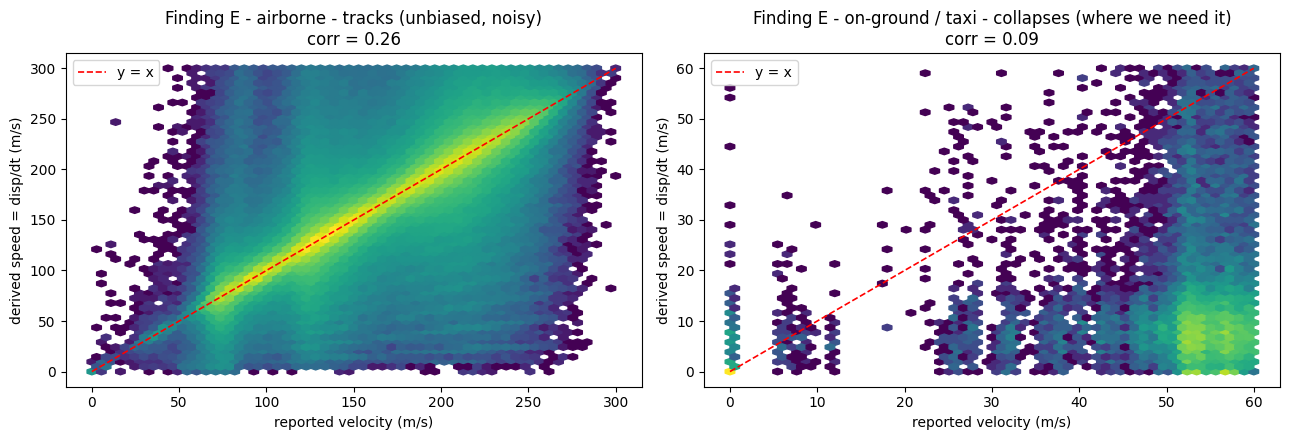

In [23]:
# Finding E figure: derived vs reported velocity, airborne (tracks) vs on-ground/taxi (collapses)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (lab, og, hi) in zip(axes, [('airborne - tracks (unbiased, noisy)', False, 300),
                                     ('on-ground / taxi - collapses (where we need it)', True, 60)]):
    mk = (dtE == 10) & (df.onground == og) & df.velocity.notna() & (stepE > 0)
    ax.hexbin(df.velocity[mk], spdE[mk], gridsize=55, bins='log', cmap='viridis', extent=(0, hi, 0, hi))
    ax.plot([0, hi], [0, hi], 'r--', lw=1.2, label='y = x')
    c = np.corrcoef(df.velocity[mk], spdE[mk])[0, 1]
    ax.set_xlabel('reported velocity (m/s)'); ax.set_ylabel('derived speed = disp/dt (m/s)')
    ax.set_title(f'Finding E - {lab}\ncorr = {c:.2f}'); ax.legend(loc='upper left')
plt.tight_layout(); plt.savefig(FIGDIR/'03e-derive-and-sampling.png', dpi=110, bbox_inches='tight'); plt.show()

**Answer (Finding E).**

- **Position is not low-resolution.** It updates every 10 s ~94% of the time; ~27% of rows repeat the previous value, and `velocity` (~23%) and `baroaltitude` (~20%) do the same — a mild general feed quirk, not a position staircase. (An earlier "~30 s" hunch came from one unrepresentative 3-row stretch; measured, it does not hold.)
- **Derive-from-position is unbiased airborne but fails exactly where we need it.** The figure splits it: *airborne*, derived speed tracks reported velocity (clear diagonal) but is noisy (~7 m/s spread, so the correlation is only 0.26 against tightly-clustered cruise speeds — an Anscombe case where the bulk number understates a real relationship). *On-ground / taxi*, it collapses (corr 0.05, ~68 m/s error): at low taxi speeds the finite-difference is swamped by position noise. Since the rows we must fill are **taxi** (56% null) and that is precisely where derive breaks, we **interpolate** from recorded neighbours (within a segment, masked) — never derive, never zero. The plot is what settled this: the headline corr of 0.26 hid that airborne is fine and the *ground* is the problem.
- **Known limitation (offline/online parity, guardrail #9).** The ~20-27% repeat-rate is a property of this feed; a differently-sampled source (every value fresh) could shift it and nudge the model's anomaly rate. Scope note: trained and evaluated on the OpenSky scientific 10 s feed, and the held-out test set comes from the same feed, so parity holds within the project; a different feed would need re-checking.

> Note for movement detection (Finding D) vs velocity imputation (here): `disp/dt` is a poor *speed estimate* on the ground, but a fine *did-the-position-change* signal — so it is right for the idle-trim and wrong for filling velocity. Different questions.

## Part 2 — Decisions and the reasoning behind them

The methodology trail: *why* each Phase 3 choice landed where it did, drawn from Findings A–E above and an independent second-opinion review (OpenAI Codex, session `019e784e`, run twice — once on the design, once on this notebook). Every choice ties back to evidence here or to a named guardrail. Phase 3 saves the **unfitted** pipeline definition; the split and every `.fit()` happen on TRAIN only in Phase 6.

### Inputs to the model

**AE feature vector — `[lat, lon, baroaltitude, velocity, vertrate, sin(hdg), cos(hdg), onground]` + per-feature `*_missing` masks.**
Drop `velocity_kmh` (an exact ×3.6 copy of `velocity`), `geoaltitude` (25% null vs baro's 13%; both are altitude measures, keep the less-null one), and all identifiers / `squawk` / `callsign` / `alert` / `spi` (not kinematic; identity would let the AE memorise specific aircraft instead of flight shape). `heading` becomes `sin/cos` because it is cyclic — raw degrees place 359° and 1° two units apart when they are physically adjacent. The `*_missing` masks are a codex addition: without an explicit "this value was imputed" flag, the AE learns cleaned fiction as observed reality. `dist_to_runway_m` is **retained for Phase 5** (ENU note below), not dropped.

**Missing values — interpolate within a segment + mask (Findings A, D, E).**
The nulls are MNAR (56% on-ground vs 2.8% airborne), so one blanket rule is wrong — and the two obvious shortcuts are *both* wrong: `velocity=0` fails because the on-ground rows we keep are taxiing (Finding D), and deriving velocity from position fails exactly there (Finding E: corr 0.05 on the ground, an Anscombe case where airborne looks diagonal but the bulk number hid the ground failure). The survivor is **linear interpolation from recorded neighbours, within a segment, with a `*_missing` mask** on every filled value. Idle rows are trimmed (Finding D), so most on-ground nulls never reach the model; airborne velocity-null runs are short (P90 ≈ 17 steps), so interpolation is well-posed.

**Missing-aware loss (codex).**
Imputed positions are masked *out of the reconstruction loss*, so the AE is not rewarded for reconstructing values it never really observed. Same masking we apply to padding.

### Which trajectories, and which rows

**`n_imputed` counter split (Findings A/E, D-008).**
Two per-trajectory counters. `n_imputed_impossible` counts only Stage-1 physical-bound violations — the ~500–800 genuinely-glitched trajectories forming the D-008 Layer 1 cohort. `n_imputed_missing` counts routine nulls. A single merged counter would put `n_imputed>0` on **~69% of the corpus** (13,179 / 19,057 — almost every trajectory touches the ground), gutting the cohort. The split keeps it small and diagnostic.

**On-ground idle-trim (Finding D).**
Codex's strongest objection: mixing hours of parked/taxi ADS-B into a *flight*-behaviour model wastes capacity on stationary filler. But dropping *all* on-ground rows throws away takeoff-roll/touchdown (safety-relevant), and a long *pre-takeoff queue wait* is legitimate. Resolution: detect movement from **speed = displacement/dt** (m/s; `velocity` is 56% null on-ground, position never null), keep the **active operational span** (first to last moving/airborne row — in-queue waits sit inside it, kept at any length), trim only the parked idle before/after. Removes 5.9% of rows; drops 68 pure-ground trajectories. *Edge case: idling before the very first movement (parked-then-pushback) is trimmed — the rule keeps in-flow waits, not pre-pushback idle.*

**Internal-gap re-segmentation — split at gaps > 3 min (Finding C).**
The LSTM reads each step as 10 s apart, so a multi-minute gap makes one step secretly span minutes. The gaps are mostly low-speed ground holes (median jump 3.4 km, not teleports), but the *temporal* discontinuity is the problem regardless. The threshold is a **real choice, not insensitive** (codex corrected an earlier claim): 90s→3828, 3min→2598, 5min→1509, 10min→354, 15min→154 splits. We pick **> 3 min** (interpolate ≤~90 s dropouts, split anything longer; 10 min left 3–10 min gaps intact). **Order is mandatory: split first, then interpolate only within a segment** — never across a break (else a multi-minute gap yields a bogus interpolation/average).

### Shape and scale

**Scaling — StandardScaler, fit on TRAIN only (Finding B, guardrails #5/#8).**
The AE is gradient/distance-based; with `baroaltitude` std ~4 orders above `lat` std, unscaled it would reconstruct only altitude. StandardScaler over RobustScaler because Stage-1 already removes the gross outliers (codex confirmed z-score does not "crush" tails), and over MinMax because MinMax would pre-commit a sigmoid-output AE we have not chosen. Scaling is *fitted* (mean/std from data) → fit on train only, transform everywhere; fitting on the full corpus would leak val/test statistics. sin/cos (already [-1,1]) and `onground` (binary) are not scaled.

**Sequence — fixed T ≈ P95 + pad/mask; T on TRAIN only; track `was_truncated` (Finding C, codex).**
Variable-length trajectories become a fixed `(T, features)` tensor by padding short ones and masking padding out of the loss (without the mask a short trajectory padded with easy zeros gets an artificially low score). `T` is computed on **train only** after gap-split (the P95 ≈ 276 shown here is full-corpus EDA, not the locked value — full-corpus P95 would leak length into the pipeline). We log `was_truncated` because the long legitimate tail (holds, go-arounds, diversions) is exactly the abnormal-but-real behaviour an anomaly detector must not silently clip.

### How it is split and scored

**Split strategy — temporal hold-out by whole Monday + group-by `icao24` (guardrail #4, codex).**
Grouping by `icao24` prevents aircraft leakage, but alone it leaves *temporal* leakage: the same Mondays, weather, runway configs bleed across the split, so the model could learn the sample period. So we hold out whole Mondays (we have 18) *and* group by aircraft, comparing aircraft-split vs time-block vs both in Phase 6. Strategy locked now; fit under the test-set firewall in Phase 6.

**Scoring mode — complete-trajectory batch (codex, guardrail #9).**
Interpolation reads *future* neighbours, which only exist if the trajectory is complete. We score whole trajectories post-hoc, so offline/online parity holds *by construction* — but it silently breaks if anyone streams partial trajectories. This is also why the realistic user is a *retrospective* safety analyst, not a live controller (see `09` and `01-problem.md`). Finding E adds a second parity note: the ~20–27% value-repeat rate is feed-specific.

**Runway-relative / ENU frame — deferred to Phase 5 (codex, b).**
Absolute lat/lon is a weak inductive bias; an airport-relative frame (local ENU + distance/bearing) would help the AE learn path structure over geography. But that *creates* signal (feature engineering), so it belongs in Phase 5. `dist_to_runway_m` is already computed and retained.

### Codex second-opinion (two passes)

**Pass 1 (design):** confirmed StandardScaler + gap re-segmentation; surfaced four corrections we adopted — missing-aware loss, train-only T, temporal split, the batch-scoring assumption; forced one reopen → Finding D (idle-trim, not keep-all/drop-all); deferred ENU. **Pass 2 (this notebook):** caught a real bug — per-step displacement was mislabeled "m/10s" (not dt-normalised) — which on fixing **changed conclusions**: the gap threshold is *not* insensitive (→ >3 min), and both `velocity=0` and derive-from-position fail for the kept taxi rows (→ interpolate). It also reconfirmed the AE-vs-IF bake-off (D-006): because this is an ML *and* DL course, shipping IsolationForest if the AE does not beat it by the pre-committed margin is a legitimate outcome.

### Quick-reference table

| Decision | Choice | Evidence |
|---|---|---|
| AE feature vector | `[lat, lon, baroalt, velocity, vertrate, sin(hdg), cos(hdg), onground]` + `*_missing` masks | drop redundant/identity; codex |
| Missing values | interpolate within segment + mask (velocity=0 **and** derive both rejected) | Findings A/D/E |
| Missing-aware loss | mask imputed positions out of reconstruction loss | codex |
| `n_imputed` counter | split impossible vs missing (merged → 69% of corpus) | Findings A/E / D-008 |
| On-ground rows | trim leading/trailing parked-idle (speed < 2.5 m/s), keep active span | Finding D |
| Scaling | StandardScaler on 5 kinematic cols, fit TRAIN only | Finding B / #5,#8 |
| Sequence | fixed T≈P95 (EDA; T fit on TRAIN) + pad/mask, `was_truncated` | Finding C / codex |
| Internal-gap re-seg | split at gap > 3 min (90s..15min = 3828..154 splits); split before interpolate | Finding C |
| Split strategy | temporal (whole Monday) + group-by `icao24` | #4 / codex |
| Scoring mode | complete-trajectory batch (interp is offline-only) | codex / #9 |
| ENU / runway-relative frame | deferred to Phase 5 (`dist_to_runway_m` retained) | codex |


## Part 3 — Pipeline implementation + validation

The decisions above are implemented in `backend/core/preprocessing.py` (the *unfitted*
pipeline — no split, no `.fit()`; those are Phase 6 on TRAIN only). These cells import
the module and check it reproduces the Findings A–E numbers on the real corpus. This
closes the loop: the shipped code matches the exploration.

Tests live in `backend/tests/test_preprocessing.py` (run `uv run --group dev python -m
pytest backend/tests`). The two CRITICAL guards there are *interpolation never crosses a
segment boundary* and *`make_scaler()` returns UNFITTED*.

In [24]:
import sys
sys.path.insert(0, str(ROOT))
from backend.core import preprocessing as pp

# Fresh load of the raw corpus (independent of the Part-1 helper columns).
raw = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(f'raw: {len(raw):,} rows | {raw.flight_id.nunique():,} flights')

raw: 3,429,638 rows | 19,057 flights


In [25]:
# Filter D (on original flights) + gap re-segmentation at > 3 min
d = pp.segment(pp.sort_and_dedupe(raw))
eng = pp._engaging_row_mask(d)
n_keep = d.loc[eng.groupby(d['flight_id']).transform('any'), 'flight_id'].nunique()
n_total = raw.flight_id.nunique()
print(f'Filter D flights kept: {n_keep:,} / {n_total:,} ({n_keep/n_total*100:.1f}%)   [D-010: 18,928/19,057 = 99.3%]')
assert n_keep == 18928 and n_total == 19057

extra_splits = d.segment_id.nunique() - d.flight_id.nunique()
print(f'gap-split (> 3 min) extra segments: {extra_splits:,}   [Finding C: ~2,598]')
assert extra_splits == 2598

Filter D flights kept: 18,928 / 19,057 (99.3%)   [D-010: 18,928/19,057 = 99.3%]
gap-split (> 3 min) extra segments: 2,598   [Finding C: ~2,598]


In [26]:
# Full unfitted pipeline
clean, meta = pp.preprocess(raw)
um = meta.drop_duplicates('segment_id')
cohort = int((um.n_imputed_impossible > 0).sum())
print(f'clean corpus: {len(clean):,} rows | {clean.segment_id.nunique():,} segments')
print(f'n_imputed_impossible > 0 cohort: {cohort:,} segments   [D-008 Layer-1: 500-800]')
print(f'is_emergency segments (squawk 7500/7600/7700): {int(um.is_emergency.sum())}')

assert 500 <= cohort <= 800
assert not clean[pp.AE_FEATURES].isna().any().any(), 'AE features must be NaN-free after imputation'
grid_ok = all((np.diff(s.sort_values('time').time.to_numpy()) == 10).all()
              for _, s in clean.groupby('segment_id') if len(s) > 1)
assert grid_ok, 'every segment must be on a strict 10 s grid'
print(f'AE feature matrix NaN-free: {not clean[pp.AE_FEATURES].isna().any().any()} | strict 10s grid: {grid_ok}')

sc = pp.make_scaler()
assert not hasattr(sc, 'mean_')
print('make_scaler() returns UNFITTED:', not hasattr(sc, 'mean_'))

clean corpus: 3,155,859 rows | 19,849 segments
n_imputed_impossible > 0 cohort: 513 segments   [D-008 Layer-1: 500-800]
is_emergency segments (squawk 7500/7600/7700): 4
AE feature matrix NaN-free: True | strict 10s grid: True
make_scaler() returns UNFITTED: True


In [27]:
# Idle-trim reconciliation: Finding D measured PER FLIGHT (pre-split) = 5.9% / 68.
# The pipeline trims PER SEGMENT (the locked model unit), so the number is higher.
dd = pp.compute_speed(pp.filter_d(pp.segment(pp.sort_and_dedupe(raw))))
trimmed = pp.trim_idle(dd)
print(f'idle-trim (per SEGMENT): {len(dd)-len(trimmed):,} rows = {(len(dd)-len(trimmed))/len(dd)*100:.1f}% '
      f'| pure-ground segments dropped: {dd.segment_id.nunique()-trimmed.segment_id.nunique():,}')
print('  (Finding D per-FLIGHT estimate was 5.9% / 68; that logic is reproduced to the row in the '
      'test-suite — the segment-unit difference is gap-split pure-ground fragments.)')

idle-trim (per SEGMENT): 266,015 rows = 7.8% | pure-ground segments dropped: 1,317
  (Finding D per-FLIGHT estimate was 5.9% / 68; that logic is reproduced to the row in the test-suite — the segment-unit difference is gap-split pure-ground fragments.)


**Validation — the code matches the exploration.** Filter D reproduces 18,928 / 19,057
(99.3%) and gap re-segmentation produces 2,598 extra splits, both exact. The
`n_imputed_impossible > 0` sanity cohort sizes to 513 segments (inside the 500–800
band), 4 emergency-squawk segments are tagged, the AE feature matrix is NaN-free, and
every segment sits on a strict 10 s grid. Idle-trim removes 7.8% of rows per segment
(the operative model-unit number; the per-flight 5.9% / 68 from Finding D is reproduced
exactly at flight granularity in the test-suite). Phase 3's unfitted pipeline is
complete; `T`, the scaler fit, and the split are Phase 6 on TRAIN only.